<a href="https://colab.research.google.com/github/Akshatha-Gadasandula/DL_LAB/blob/main/week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


<Figure size 1200x1200 with 0 Axes>

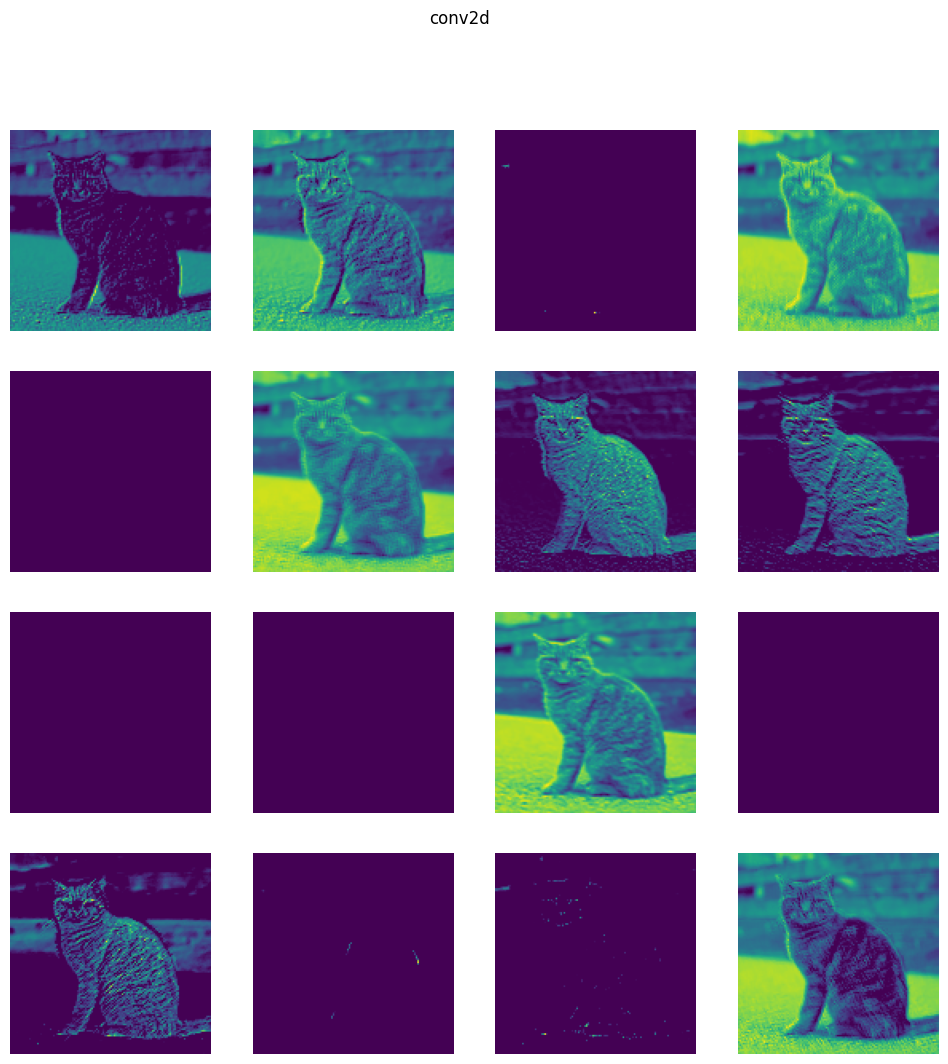

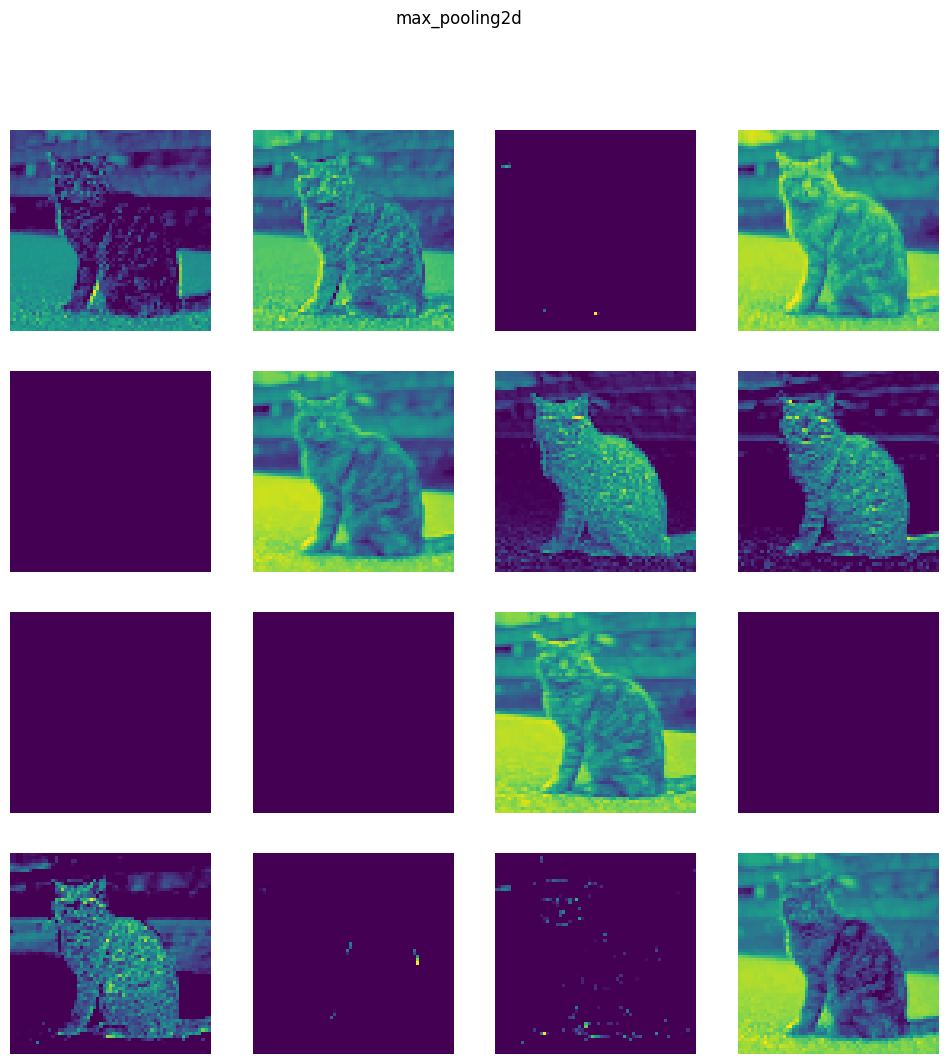

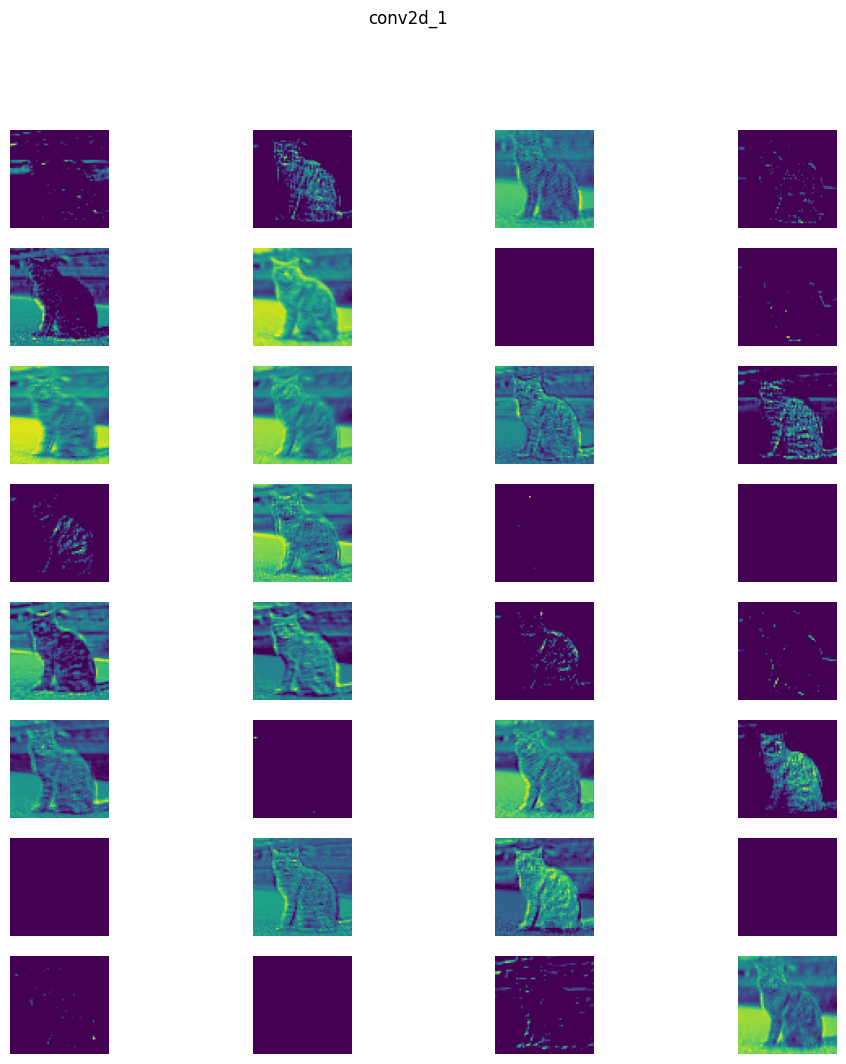

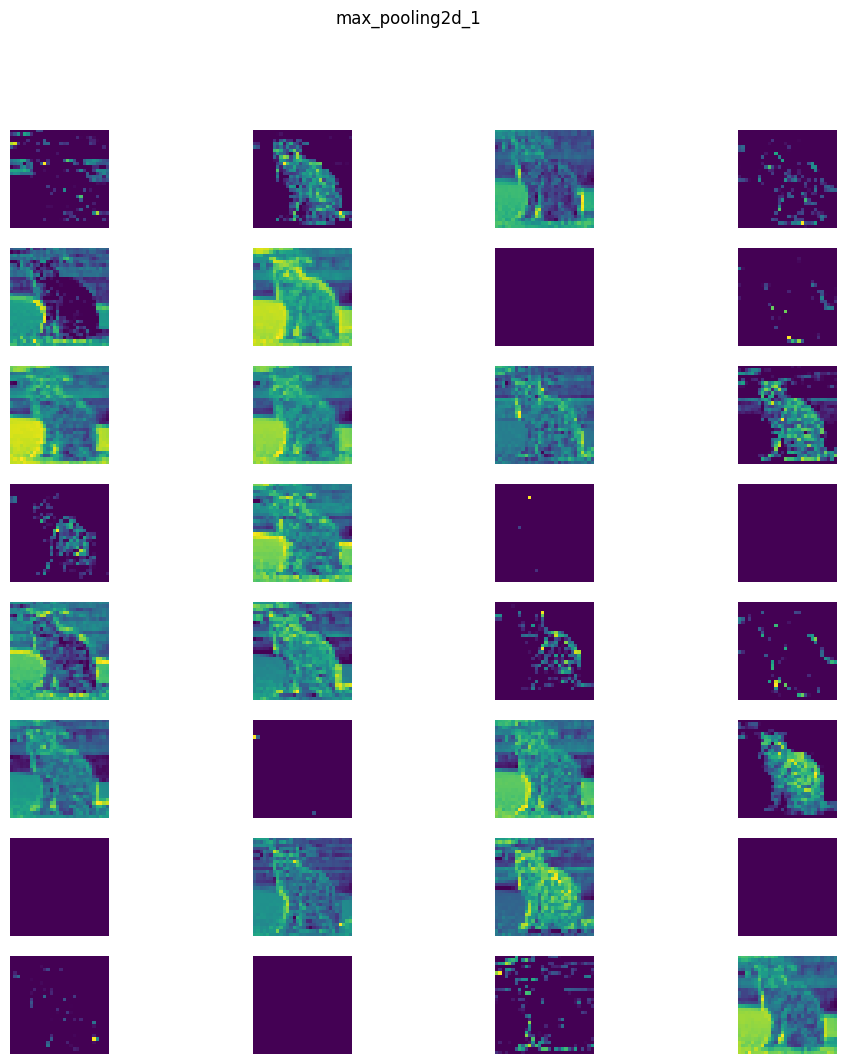

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess image
img_path = '/content/cat.png'  # Replace with your image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Build CNN model using Functional API
input_tensor = Input(shape=(128, 128, 3), name='input_layer')
x = layers.Conv2D(16, (3,3), activation='relu', name='conv2d')(input_tensor)
x = layers.MaxPooling2D((2,2), name='max_pooling2d')(x)
x = layers.Conv2D(32, (3,3), activation='relu', name='conv2d_1')(x)
output_tensor = layers.MaxPooling2D((2,2), name='max_pooling2d_1')(x)

model = models.Model(inputs=input_tensor, outputs=output_tensor)

# Create a model that outputs intermediate layers
# Now model.input is explicitly defined as input_tensor
layer_outputs = [layer.output for layer in model.layers]
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

# Get feature maps
activations = activation_model.predict(img_array)

# Function to plot feature maps
def plot_feature_maps(activations, layer_names):
    for i, activation in enumerate(activations):
        layer_name = layer_names[i]
        n_features = activation.shape[-1]

        size = activation.shape[1]
        cols = 4
        rows = n_features // cols

        plt.figure(figsize=(12, 12))
        plt.suptitle(layer_name)

        for j in range(rows * cols):
            plt.subplot(rows, cols, j+1)
            plt.imshow(activation[0, :, :, j], cmap='viridis')
            plt.axis('off')

        plt.show()

# Layer names
layer_names = [layer.name for layer in model.layers]

# Visualize
plot_feature_maps(activations, layer_names)


OBSERVATIONS:Convolution highlights edges and textures of the cat image.
Different filters capture different features like whiskers and ears.
Pooling reduces size and removes minor details.
Important features remain while background fades.
Deeper layers show more abstract representation of the cat.